# BraTS 2021 — 3D U-Net Brain Tumor Segmentation

A clean notebook containing **only the final workflow**: data preparation, training, native-space evaluation, and generation of the publication figures.

**Note 1:** Some paths (e.g. `C:\BraTS2021`) come from the original Windows environment. The data folder can be changed with the `BRATS_DIR` environment variable or by editing `DATASET_DIR` in the extraction and data-listing cells (sections 2 and 3) before running.

**Note 2 (revised version):** This version (a) adds the missing `train_test_split` import, (b) removes the old evaluation cell (it compared against a downsampled-then-upsampled ground truth and ended with a `MemoryError`) and makes cell 8.1 the single source of evaluation, (c) adds cell 8.2, which builds the patient-level CSV with the HD95 penalty applied explicitly, (d) adds peak-GPU-memory and inference-time measurements, and (e) fixes the qualitative figures (sagittal slice and FLAIR channel).

**Note 3:** The outputs of the modified cells, and of the cells that depend on them, were **deliberately cleared**; re-run them to obtain consistent results. The training outputs were kept (the training log only reaches epoch 13 because training was resumed from a checkpoint).

## 1. Environment Check

In [1]:
import torch
import torchvision
import torchaudio
import monai

print("=== ENVIRONMENT CHECK ===")
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("TorchAudio:", torchaudio.__version__)
print("MONAI:", monai.__version__)

print("\n=== CUDA CHECK ===")
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

=== ENVIRONMENT CHECK ===
PyTorch: 2.8.0+cu128
TorchVision: 0.23.0+cu128
TorchAudio: 2.8.0+cu128
MONAI: 1.6.0

=== CUDA CHECK ===
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
GPU count: 1
GPU memory: 6.0 GB


## 2. Downloading the BraTS 2021 Dataset

In [ ]:
pip install kagglehub

In [11]:
import kagglehub

# Specify the dataset ID for BraTS 2021 (Task 1)
dataset_id = "dschettler8845/brats-2021-task1"

print("Downloading BraTS 2021 data, this may take a while due to its large size...")
path = kagglehub.dataset_download(dataset_id)

print(f"Download successful! Files are located at:\n{path}")

⏳ Téléchargement des données BraTS 2021 en cours, cela peut prendre un certain temps en raison de la taille importante...
Resuming download from 12157190144 bytes (1037583815 bytes left)...
Resuming download to C:\Users\eraze\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\1.archive (12157190144/13194773959) bytes left.


100%|█████████████████████████████████████████████████████████████████████████████| 12.3G/12.3G [06:01<00:00, 2.87MB/s]

Extracting files...


✅ Téléchargement réussi ! Les fichiers sont situés dans le chemin suivant :
C:\Users\eraze\.cache\kagglehub\datasets\dschettler8845\brats-2021-task1\versions\1


In [13]:
import tarfile
import os

# `path` comes from kagglehub.dataset_download() in the previous cell
tar_path = os.path.join(path, "BraTS2021_Training_Data.tar")

DATASET_DIR = os.environ.get("BRATS_DIR", r"C:\BraTS2021")
extract_path = DATASET_DIR

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path)

print("Extraction completed.")

Extraction completed.


In [2]:
import os

DATASET_DIR = os.environ.get("BRATS_DIR", r"C:\BraTS2021")
dataset_path = DATASET_DIR

patients = sorted([
    f for f in os.listdir(dataset_path)
    if f.startswith("BraTS2021_")
])

print("Number of patients:", len(patients))

patient_path = os.path.join(dataset_path, patients[0])

print("\nFirst patient:", patients[0])
print(os.listdir(patient_path))

Number of patients: 1251

First patient: BraTS2021_00000
['BraTS2021_00000_flair.nii.gz', 'BraTS2021_00000_seg.nii.gz', 'BraTS2021_00000_t1.nii.gz', 'BraTS2021_00000_t1ce.nii.gz', 'BraTS2021_00000_t2.nii.gz']


### Quick Preview of a Single Case (Optional)

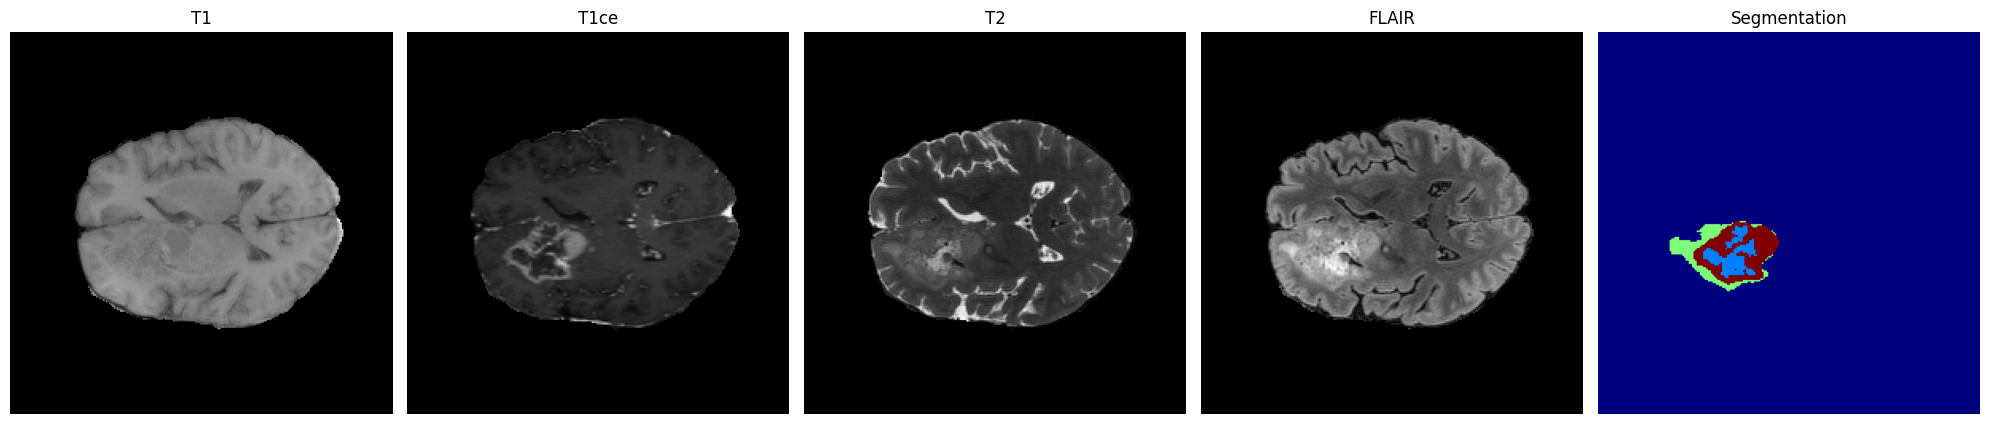

In [3]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

# Dataset path
dataset_path = r"C:\BraTS2021"

# List of patients (ignoring .DS_Store)
patients = sorted([
    p for p in os.listdir(dataset_path)
    if p.startswith("BraTS2021_")
])

# Select the first patient
patient = patients[0]
patient_path = os.path.join(dataset_path, patient)

# Load the images
t1 = nib.load(os.path.join(patient_path, f"{patient}_t1.nii.gz")).get_fdata()
t1ce = nib.load(os.path.join(patient_path, f"{patient}_t1ce.nii.gz")).get_fdata()
t2 = nib.load(os.path.join(patient_path, f"{patient}_t2.nii.gz")).get_fdata()
flair = nib.load(os.path.join(patient_path, f"{patient}_flair.nii.gz")).get_fdata()
seg = nib.load(os.path.join(patient_path, f"{patient}_seg.nii.gz")).get_fdata()

# Select the middle slice
slice_idx = t1.shape[2] // 2

# Display the images
fig, axes = plt.subplots(1, 5, figsize=(20,5))

titles = ["T1", "T1ce", "T2", "FLAIR", "Segmentation"]
images = [t1, t1ce, t2, flair, seg]
cmaps = ["gray", "gray", "gray", "gray", "jet"]

for ax, img, title, cmap in zip(axes, images, titles, cmaps):
    ax.imshow(img[:, :, slice_idx], cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Building and Splitting the Data Lists (Train / Validation / Test)

In [7]:
data = []

for patient in patients:

    patient_path = os.path.join(dataset_path, patient)

    data.append({
        "image": [
            os.path.join(patient_path, f"{patient}_t1.nii.gz"),
            os.path.join(patient_path, f"{patient}_t1ce.nii.gz"),
            os.path.join(patient_path, f"{patient}_t2.nii.gz"),
            os.path.join(patient_path, f"{patient}_flair.nii.gz"),
        ],
        "label": os.path.join(patient_path, f"{patient}_seg.nii.gz"),
    })

print("Total Cases:", len(data))
print(data[0])

Total Cases: 1251
{'image': ['C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t1.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t1ce.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_t2.nii.gz', 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_flair.nii.gz'], 'label': 'C:\\BraTS2021\\BraTS2021_00000\\BraTS2021_00000_seg.nii.gz'}


In [8]:
from sklearn.model_selection import train_test_split

train_files, test_files = train_test_split(
    data,
    test_size=0.15,
    random_state=42
)

train_files, val_files = train_test_split(
    train_files,
    test_size=0.1765,
    random_state=42
)

print("Training :", len(train_files))
print("Validation:", len(val_files))
print("Testing :", len(test_files))

Training : 875
Validation: 188
Testing : 188


## 4. Transforms and Converting Labels to WT / TC / ET

In [39]:
import torch
from monai.transforms import MapTransform

class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):

    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)

        for key in self.keys:

            label = d[key]

            if label.shape[0] == 1:
                label = label.squeeze(0)

            d[key] = torch.stack(
                [
                    ((label == 1) | (label == 2) | (label == 4)).float(),  # WT
                    ((label == 1) | (label == 4)).float(),                 # TC
                    (label == 4).float(),                                  # ET
                ],
                dim=0,
            )

        return d

In [40]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    NormalizeIntensityd,
    ResizeD,
    EnsureTyped,
)

train_transforms = Compose([

    LoadImaged(keys=["image", "label"]),

    EnsureChannelFirstd(keys=["image", "label"]),

    Orientationd(
        keys=["image", "label"],
        axcodes="RAS"
    ),

    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True
    ),

    ResizeD(
        keys=["image", "label"],
        spatial_size=(128, 128, 128),
        mode=("trilinear", "nearest")
    ),

    ConvertToMultiChannelBasedOnBratsClassesd(
        keys=["label"]
    ),

    EnsureTyped(
        keys=["image", "label"]
    )

])

In [58]:
from monai.data import Dataset

train_dataset = Dataset(
    data=train_files,
    transform=train_transforms
)

val_dataset = Dataset(
    data=val_files,
    transform=train_transforms
)

test_dataset = Dataset(
    data=test_files,
    transform=train_transforms
)

In [59]:
from monai.data import DataLoader

BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

## 5. Model Definition (3D U-Net) and Training Setup

In [52]:
import torch
from monai.networks.nets import UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

print(model)
print("\nDevice:", device)

AttributeError: module 'torch._C' has no attribute '_get_all_dtypes'

In [33]:
from monai.losses import DiceLoss

criterion = DiceLoss(
    sigmoid=True,
    squared_pred=True,
    reduction="mean"
)

In [34]:
import torch

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

In [24]:
from torch import amp

scaler = amp.GradScaler("cuda")

## 6. Training

Final training loop: supports resuming training from the last checkpoint, and saves both the best model (`best_model.pth`) and a full checkpoint (`checkpoint.pth`) after every epoch.

In [63]:
import os
import time
import torch
from torch import amp

EPOCHS = 20

checkpoint_path = "checkpoint.pth"
best_model_path = "best_model.pth"

start_epoch = 0
best_val_loss = float("inf")

####################################################
# Load the latest checkpoint if it exists
####################################################
if os.path.exists(checkpoint_path):

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]

    print("="*60)
    print(f"Resume training from Epoch {start_epoch+1}")
    print("="*60)

####################################################
# If no checkpoint exists but a best model does
####################################################
elif os.path.exists(best_model_path):

    model.load_state_dict(torch.load(best_model_path, map_location=device))

    print("="*60)
    print("Loaded best_model.pth")
    print("Training will continue from this model.")
    print("="*60)

####################################################
# If nothing exists
####################################################
else:

    print("="*60)
    print("No checkpoint found.")
    print("Training from scratch.")
    print("="*60)

####################################################
# Training
####################################################
for epoch in range(start_epoch, EPOCHS):

    start_time = time.time()

    ##############################
    # TRAIN
    ##############################
    model.train()

    running_train_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):

        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with amp.autocast("cuda"):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:

            print(
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Batch [{batch_idx+1}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f}"
            )

    avg_train_loss = running_train_loss / len(train_loader)

    ##############################
    # VALIDATION
    ##############################
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for batch in val_loader:

            images = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            with amp.autocast("cuda"):

                outputs = model(images)
                loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    ##############################
    # Save the best model
    ##############################
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(model.state_dict(), best_model_path)

        print("Best model saved.")

    ##############################
    # Save checkpoint
    ##############################
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_loss": best_val_loss,
    }, checkpoint_path)

    ##############################
    # Epoch summary
    ##############################
    print("\n===================================================")
    print(f"Epoch           : {epoch+1}/{EPOCHS}")
    print(f"Train Loss      : {avg_train_loss:.4f}")
    print(f"Validation Loss : {avg_val_loss:.4f}")
    print(f"Best Val Loss   : {best_val_loss:.4f}")
    print(f"Time            : {time.time()-start_time:.1f} seconds")
    print("Checkpoint saved.")
    print("===================================================\n")

print("Training Finished.")

C:\Users\eraze\AppData\Local\Temp\ipykernel_21816\3804207891.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locat

Loaded best_model.pth
Training will continue from this model.
Epoch [1/20] Batch [20/875] Loss: 0.0866
Epoch [1/20] Batch [40/875] Loss: 0.3505
Epoch [1/20] Batch [60/875] Loss: 0.1236
Epoch [1/20] Batch [80/875] Loss: 0.1556
Epoch [1/20] Batch [100/875] Loss: 0.4866
Epoch [1/20] Batch [120/875] Loss: 0.3789
Epoch [1/20] Batch [140/875] Loss: 0.1335
Epoch [1/20] Batch [160/875] Loss: 0.2519
Epoch [1/20] Batch [180/875] Loss: 0.1993
Epoch [1/20] Batch [200/875] Loss: 0.1169
Epoch [1/20] Batch [220/875] Loss: 0.2738
Epoch [1/20] Batch [240/875] Loss: 0.3465
Epoch [1/20] Batch [260/875] Loss: 0.3245
Epoch [1/20] Batch [280/875] Loss: 0.1481
Epoch [1/20] Batch [300/875] Loss: 0.1193
Epoch [1/20] Batch [320/875] Loss: 0.1081
Epoch [1/20] Batch [340/875] Loss: 0.2364
Epoch [1/20] Batch [360/875] Loss: 0.1300
Epoch [1/20] Batch [380/875] Loss: 0.0909
Epoch [1/20] Batch [400/875] Loss: 0.1064
Epoch [1/20] Batch [420/875] Loss: 0.1730
Epoch [1/20] Batch [440/875] Loss: 0.0515
Epoch [1/20] Batch

KeyboardInterrupt: 

## 7. Loading the Best Model for Evaluation

In [82]:
import torch
from monai.networks.nets import UNet

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

checkpoint = torch.load(
    "best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint)
model.eval()

print("Device:", device)
print("Model loaded successfully.")

AttributeError: module 'torch._C' has no attribute '_get_all_dtypes'

## 7.1 Peak GPU Memory and Inference Time

These two cells produce the figures reported in the README (peak GPU memory of one training step, and per-case inference time).
For a clean number, restart the kernel and run only the essential cells (data, transforms, DataLoaders) before this cell, so that other models do not occupy GPU memory.

In [ ]:
import torch
from torch import amp
from monai.networks.nets import UNet
from monai.losses import DiceLoss

assert torch.cuda.is_available(), "GPU memory measurement requires CUDA"
device = torch.device("cuda")

# Same architecture / loss / optimizer / AMP settings as the training cells
mem_model = UNet(
    spatial_dims=3, in_channels=4, out_channels=3,
    channels=(32, 64, 128, 256, 512), strides=(2, 2, 2, 2), num_res_units=2,
).to(device)
mem_model.train()
mem_criterion = DiceLoss(sigmoid=True, squared_pred=True, reduction="mean")
mem_optimizer = torch.optim.Adam(mem_model.parameters(), lr=1e-4, weight_decay=1e-5)
mem_scaler = amp.GradScaler("cuda")

batch = next(iter(train_loader))
images = batch["image"].to(device)
labels = batch["label"].to(device)

torch.cuda.synchronize()
torch.cuda.empty_cache()
baseline_mb = torch.cuda.memory_allocated() / 1024**2
torch.cuda.reset_peak_memory_stats()

N_STEPS = 3   # step 1 also creates the Adam state, so take the peak over several steps
for _ in range(N_STEPS):
    mem_optimizer.zero_grad(set_to_none=True)
    with amp.autocast("cuda"):
        outputs = mem_model(images)
        loss = mem_criterion(outputs, labels)
    mem_scaler.scale(loss).backward()
    mem_scaler.step(mem_optimizer)
    mem_scaler.update()
torch.cuda.synchronize()

peak_alloc = torch.cuda.max_memory_allocated() / 1024**2
peak_resv = torch.cuda.max_memory_reserved() / 1024**2
print(f"Allocated before the steps : {baseline_mb:8.2f} MB (model + one batch)")
print(f"Peak allocated             : {peak_alloc:8.2f} MB")
print(f"Peak reserved              : {peak_resv:8.2f} MB")
print(f"GPU                        : {torch.cuda.get_device_name(0)}")

del mem_model, mem_optimizer, mem_scaler, outputs, loss, images, labels
torch.cuda.empty_cache()

In [ ]:
import time
import numpy as np
import torch

# `model` is the best checkpoint loaded in the previous section (fp32, eval mode)
model.eval()

N_CASES = 50     # number of test cases to time (use len(test_loader) for all 188)
N_WARMUP = 3     # first cases are excluded (CUDA / cuDNN warm-up)

times_ms = []
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        if i >= N_CASES + N_WARMUP:
            break
        x = batch["image"].to(device)          # data loading is NOT included in the timing
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        probs = torch.sigmoid(model(x))        # forward pass + sigmoid, 128^3 grid
        torch.cuda.synchronize()
        times_ms.append((time.perf_counter() - t0) * 1000.0)

times_ms = np.array(times_ms[N_WARMUP:])
print(f"Timed cases : {len(times_ms)}")
print(f"Mean   : {times_ms.mean():.2f} ms/case")
print(f"Median : {np.median(times_ms):.2f} ms/case")
print(f"SD     : {times_ms.std(ddof=1):.2f} ms")
print("Scope  : model forward + sigmoid on the 128^3 grid; excludes loading, resizing to native space and metrics.")

## 8. Native-Space Evaluation

The model probabilities are upsampled from the network resolution (128³) to the image's native space (240×240×155) **before** the 0.5 threshold is applied; Dice and HD95 are then computed against the original segmentation file (converted to RAS).

**8.1** Detailed per-region evaluation (WT/TC/ET) with volumes → `Native_Space_Metrics_WT_TC_ET.csv` (used by Figure 5 and cell 8.2).

In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import nibabel as nib

from scipy.ndimage import binary_erosion, distance_transform_edt


# ============================================================
# SETTINGS
# ============================================================

NATIVE_SIZE = (240, 240, 155)
NATIVE_SPACING = (1.0, 1.0, 1.0)
THRESHOLD = 0.5


# ============================================================
# DICE
# ============================================================

def dice_score(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    pred_sum = pred.sum()
    gt_sum = gt.sum()

    if pred_sum == 0 and gt_sum == 0:
        return 1.0

    if pred_sum == 0 or gt_sum == 0:
        return 0.0

    intersection = np.logical_and(pred, gt).sum()

    return (
        2.0 * intersection
        / (pred_sum + gt_sum)
    )


# ============================================================
# HD95
# ============================================================

def hd95(pred, gt, spacing=(1.0, 1.0, 1.0)):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    # Both empty
    if not pred.any() and not gt.any():
        return 0.0

    # One empty
    if not pred.any() or not gt.any():
        return np.nan

    pred_surface = pred ^ binary_erosion(pred)
    gt_surface = gt ^ binary_erosion(gt)

    dt_gt = distance_transform_edt(
        ~gt_surface,
        sampling=spacing
    )

    dt_pred = distance_transform_edt(
        ~pred_surface,
        sampling=spacing
    )

    distances_pred_to_gt = dt_gt[pred_surface]
    distances_gt_to_pred = dt_pred[gt_surface]

    distances = np.concatenate([
        distances_pred_to_gt,
        distances_gt_to_pred
    ])

    return np.percentile(distances, 95)


# ============================================================
# LOAD NATIVE LABEL IN RAS
# ============================================================

def load_native_label_ras(label_path):

    nii = nib.load(label_path)

    # Convert original orientation -> RAS
    nii_ras = nib.as_closest_canonical(nii)

    label = nii_ras.get_fdata()

    label = np.squeeze(label)

    # Check native dimensions
    if label.shape != NATIVE_SIZE:

        raise ValueError(
            f"Unexpected native shape: {label.shape}, "
            f"expected {NATIVE_SIZE}"
        )

    # Check native spacing
    spacing = nii_ras.header.get_zooms()[:3]

    print("Native RAS shape:", label.shape)
    print("Native RAS spacing:", spacing)

    return label


# ============================================================
# BRATS REGIONS
# ============================================================

def get_brats_regions(label):

    WT = (
        (label == 1) |
        (label == 2) |
        (label == 4)
    )

    TC = (
        (label == 1) |
        (label == 4)
    )

    ET = (
        label == 4
    )

    return WT, TC, ET


# ============================================================
# EVALUATION
# ============================================================

model.eval()

results = []


with torch.no_grad():

    for patient_id, batch in enumerate(test_loader):

        print("\n======================================")
        print(f"Patient {patient_id + 1:03d}")
        print("======================================")

        # ----------------------------------------------------
        # IMAGE
        # ----------------------------------------------------

        image = batch["image"].to(device)

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        output = model(image)

        probabilities = torch.sigmoid(output)

        print(
            "Probability shape:",
            tuple(probabilities.shape)
        )

        # ----------------------------------------------------
        # RESIZE PROBABILITIES
        #
        # 128³ -> 240×240×155
        #
        # IMPORTANT:
        # interpolation is applied BEFORE threshold
        # ----------------------------------------------------

        probabilities_native = F.interpolate(
            probabilities,
            size=NATIVE_SIZE,
            mode="trilinear",
            align_corners=False
        )

        # ----------------------------------------------------
        # THRESHOLD IN NATIVE SPACE
        # ----------------------------------------------------

        prediction_native = (
            probabilities_native > THRESHOLD
        )

        prediction_native = (
            prediction_native
            .cpu()
            .numpy()[0]
        )

        # ----------------------------------------------------
        # ORIGINAL LABEL PATH
        # ----------------------------------------------------

        label_path = (
            batch["label"]
            .meta["filename_or_obj"]
        )

        if isinstance(label_path, (list, tuple)):
            label_path = label_path[0]

        print("Label:", label_path)

        # ----------------------------------------------------
        # LOAD NATIVE LABEL AND CONVERT TO RAS
        # ----------------------------------------------------

        native_label = load_native_label_ras(
            label_path
        )

        # ----------------------------------------------------
        # CREATE WT / TC / ET
        # ----------------------------------------------------

        gt_WT, gt_TC, gt_ET = get_brats_regions(
            native_label
        )

        # ----------------------------------------------------
        # PREDICTION CHANNELS
        # ----------------------------------------------------

        pred_WT = prediction_native[0]
        pred_TC = prediction_native[1]
        pred_ET = prediction_native[2]

        # ----------------------------------------------------
        # DICE
        # ----------------------------------------------------

        dice_WT = dice_score(
            pred_WT,
            gt_WT
        )

        dice_TC = dice_score(
            pred_TC,
            gt_TC
        )

        dice_ET = dice_score(
            pred_ET,
            gt_ET
        )

        # ----------------------------------------------------
        # HD95
        # ----------------------------------------------------

        hd_WT = hd95(
            pred_WT,
            gt_WT,
            NATIVE_SPACING
        )

        hd_TC = hd95(
            pred_TC,
            gt_TC,
            NATIVE_SPACING
        )

        hd_ET = hd95(
            pred_ET,
            gt_ET,
            NATIVE_SPACING
        )

        # ----------------------------------------------------
        # VOLUMES
        #
        # 1 voxel = 1 mm³
        # ----------------------------------------------------

        pred_WT_volume_cm3 = (
            pred_WT.sum() / 1000.0
        )

        pred_TC_volume_cm3 = (
            pred_TC.sum() / 1000.0
        )

        pred_ET_volume_cm3 = (
            pred_ET.sum() / 1000.0
        )

        gt_WT_volume_cm3 = (
            gt_WT.sum() / 1000.0
        )

        gt_TC_volume_cm3 = (
            gt_TC.sum() / 1000.0
        )

        gt_ET_volume_cm3 = (
            gt_ET.sum() / 1000.0
        )

        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        results.append([
            patient_id + 1,

            dice_WT,
            dice_TC,
            dice_ET,

            hd_WT,
            hd_TC,
            hd_ET,

            pred_WT_volume_cm3,
            pred_TC_volume_cm3,
            pred_ET_volume_cm3,

            gt_WT_volume_cm3,
            gt_TC_volume_cm3,
            gt_ET_volume_cm3
        ])

        # ----------------------------------------------------
        # PRINT
        # ----------------------------------------------------

        print(
            f"WT | DSC={dice_WT:.4f} | "
            f"HD95={hd_WT:.2f} mm | "
            f"PredVol={pred_WT_volume_cm3:.2f} cm³"
        )

        print(
            f"TC | DSC={dice_TC:.4f} | "
            f"HD95={hd_TC:.2f} mm | "
            f"PredVol={pred_TC_volume_cm3:.2f} cm³"
        )

        print(
            f"ET | DSC={dice_ET:.4f} | "
            f"HD95={hd_ET:.2f} mm | "
            f"PredVol={pred_ET_volume_cm3:.2f} cm³"
        )


# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(
    results,
    columns=[
        "Patient",

        "DSC_WT",
        "DSC_TC",
        "DSC_ET",

        "HD95_WT_mm",
        "HD95_TC_mm",
        "HD95_ET_mm",

        "Pred_Volume_WT_cm3",
        "Pred_Volume_TC_cm3",
        "Pred_Volume_ET_cm3",

        "GT_Volume_WT_cm3",
        "GT_Volume_TC_cm3",
        "GT_Volume_ET_cm3"
    ]
)


# ============================================================
# SAVE
# ============================================================

df.to_csv(
    "Native_Space_Metrics_WT_TC_ET.csv",
    index=False
)


# ============================================================
# FINAL STATISTICS
# ============================================================

print("\n======================================")
print("NATIVE-SPACE FINAL RESULTS")
print("======================================")


print("\nMean DSC")
print(f"WT : {df['DSC_WT'].mean():.4f}")
print(f"TC : {df['DSC_TC'].mean():.4f}")
print(f"ET : {df['DSC_ET'].mean():.4f}")


print("\nSD DSC")
print(f"WT : {df['DSC_WT'].std():.4f}")
print(f"TC : {df['DSC_TC'].std():.4f}")
print(f"ET : {df['DSC_ET'].std():.4f}")


print("\nMean HD95")
print(f"WT : {df['HD95_WT_mm'].mean():.4f} mm")
print(f"TC : {df['HD95_TC_mm'].mean():.4f} mm")
print(f"ET : {df['HD95_ET_mm'].mean():.4f} mm")


print("\nSD HD95")
print(f"WT : {df['HD95_WT_mm'].std():.4f} mm")
print(f"TC : {df['HD95_TC_mm'].std():.4f} mm")
print(f"ET : {df['HD95_ET_mm'].std():.4f} mm")


print("\nMean Predicted Volumes")
print(
    f"WT : {df['Pred_Volume_WT_cm3'].mean():.4f} cm³"
)
print(
    f"TC : {df['Pred_Volume_TC_cm3'].mean():.4f} cm³"
)
print(
    f"ET : {df['Pred_Volume_ET_cm3'].mean():.4f} cm³"
)


print("\n======================================")
print("Saved:")
print("Native_Space_Metrics_WT_TC_ET.csv")
print("======================================")

**8.2** Patient-level CSV → used for Figures 3 and 4 and for the README numbers.

- `Patient_Dice` = mean Dice over the three regions.
- `Patient_HD95_mm` = mean HD95 over the three regions, after replacing undefined values (empty region in the prediction or in the ground truth) with a **373.13 mm** penalty (image diagonal √(240²+240²+155²)).

In [ ]:
import numpy as np
import pandas as pd

EMPTY_MASK_PENALTY = float(np.sqrt(240**2 + 240**2 + 155**2))   # 373.13 mm
dsc_cols = ["DSC_WT", "DSC_TC", "DSC_ET"]
hd_cols = ["HD95_WT_mm", "HD95_TC_mm", "HD95_ET_mm"]

df_regions = pd.read_csv("Native_Space_Metrics_WT_TC_ET.csv")
assert len(df_regions) == 188, f"expected 188 test cases, got {len(df_regions)}"

n_penalized = df_regions[hd_cols].isna().sum()
print(f"Penalty value: {EMPTY_MASK_PENALTY:.2f} mm")
print("Penalised cases per region:", n_penalized.to_dict())

df_patient = pd.DataFrame({
    "Patient": df_regions["Patient"].astype(int),
    "Patient_Dice": df_regions[dsc_cols].mean(axis=1),
    "Patient_HD95_mm": df_regions[hd_cols].fillna(EMPTY_MASK_PENALTY).mean(axis=1),
})
df_patient.to_csv("Native_Space_HD95_DSC_188_patients.csv", index=False)

# ---- overall statistics (what the README reports) ----
rng = np.random.default_rng(42)
def bootstrap_ci(x, n_boot=10000):
    x = np.asarray(x, dtype=float)
    idx = rng.integers(0, len(x), size=(n_boot, len(x)))
    return np.percentile(x[idx].mean(axis=1), [2.5, 97.5])

d = df_patient["Patient_Dice"].to_numpy()
h = df_patient["Patient_HD95_mm"].to_numpy()
d_lo, d_hi = bootstrap_ci(d)
h_lo, h_hi = bootstrap_ci(h)
q1, q3 = np.quantile(h, [0.25, 0.75])

print("\n=== OVERALL (per-patient, N=%d) ===" % len(d))
print(f"DSC  : mean {d.mean():.4f} (95% CI {d_lo:.4f}-{d_hi:.4f}), median {np.median(d):.4f}, SD {d.std(ddof=1):.4f}")
print(f"HD95 : mean {h.mean():.2f} mm (95% CI {h_lo:.2f}-{h_hi:.2f}), median {np.median(h):.2f} mm, IQR {q1:.2f}-{q3:.2f}")
print("CI method: percentile bootstrap, 10,000 resamples of patients, seed 42")
print("\nSaved: Native_Space_HD95_DSC_188_patients.csv")

## 9. Model Complexity (FLOPs / MACs)

In [53]:
%pip install -U fvcore

Note: you may need to restart the kernel to use updated packages.Collecting fvcore
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61446 sha256=a9103286aa241dd91eda31c4e55755ee967230e697586ea6124821fcb75243ee
  Stored in directory: c:\users\eraze\appdata\local\pip\cache\wheels\01\c0\af\77c1cf53a1be9e42

In [55]:
%pip install -U ptflops

In [54]:
# ============================================================
# I1 — VERIFY MODEL FLOPs / MACs
# ============================================================

import torch
from fvcore.nn import FlopCountAnalysis, flop_count_table

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

dummy_input = torch.randn(
    1, 4, 128, 128, 128,
    device=device
)

# ------------------------------------------------------------
# FLOP analysis
# ------------------------------------------------------------

flops = FlopCountAnalysis(
    model,
    dummy_input
)

flops.unsupported_ops_warnings(False)

total_flops = flops.total()

print("=" * 70)
print("I1 — FLOPs VERIFICATION")
print("=" * 70)

print(f"Total FLOPs (fvcore): {total_flops:,.0f}")
print(f"Total GFLOPs        : {total_flops / 1e9:.4f}")

print("\n" + "=" * 70)
print("BY OPERATOR")
print("=" * 70)

print(flops.by_operator())

print("\n" + "=" * 70)
print("UNSUPPORTED OPERATORS")
print("=" * 70)

print(flops.unsupported_ops())

print("\n" + "=" * 70)
print("MODULE-LEVEL FLOP TABLE")
print("=" * 70)

print(
    flop_count_table(
        flops,
        max_depth=4
    )
)

print("\n" + "=" * 70)
print("I1 COMPLETE")
print("=" * 70)

I1 — FLOPs VERIFICATION
Total FLOPs (fvcore): 48,797,581,312
Total GFLOPs        : 48.7976

BY OPERATOR
Counter({'conv': 48593108992, 'instance_norm': 204472320})

UNSUPPORTED OPERATORS
Counter({'aten::prelu': 17, 'aten::add': 9})

MODULE-LEVEL FLOP TABLE
| module                                          | #parameters or shape   | #flops   |
|:------------------------------------------------|:-----------------------|:---------|
| model                                           | 19.224M                | 48.798G  |
| 0                                               | 34.658K                | 9.127G   |
| 0.conv                                          | 31.17K                 | 8.221G   |
| 0.conv.unit0                                    | 3.489K                 | 0.94G    |
| 0.conv.unit0.conv                               | 3.488K                 | 0.906G   |
| 0.conv.unit0.adn                                | 1                      | 33.554M  |
| 0.conv.unit1                          

In [56]:
import torch
from ptflops import get_model_complexity_info

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

macs, params = get_model_complexity_info(
    model,
    (4, 128, 128, 128),
    as_strings=False,
    print_per_layer_stat=False,
    verbose=False
)

print("=" * 70)
print("I1 — PTFlops CROSS-CHECK")
print("=" * 70)

print(f"MACs       : {macs:,.0f}")
print(f"GMACs      : {macs / 1e9:.4f}")

print(f"Parameters : {params:,.0f}")
print(f"Millions   : {params / 1e6:.4f}")

print(f"\nFLOPs (2 × MACs) : {2 * macs / 1e9:.4f} GFLOPs")

print("=" * 70)
print("I1 PTFlops COMPLETE")
print("=" * 70)

I1 — PTFlops CROSS-CHECK
MACs       : 48,815,276,032
GMACs      : 48.8153
Parameters : 19,223,978
Millions   : 19.2240

FLOPs (2 × MACs) : 97.6306 GFLOPs
I1 PTFlops COMPLETE


## 10. Quantitative Publication Figures

### Figure 3 — Per-Patient Dice

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# FIGURE 3 — Per-patient Dice Coefficient
# FINAL NATIVE-SPACE TEST RESULTS
# N = 188
# Publication-ready version
# ============================================================

# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

output_dir = "saved"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 2. Load FINAL patient-level test results
# ------------------------------------------------------------

csv_file = "Native_Space_HD95_DSC_188_patients.csv"

df = pd.read_csv(csv_file)

# ------------------------------------------------------------
# 3. Check required columns
# ------------------------------------------------------------

required_columns = ["Patient", "Patient_Dice"]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# 4. Extract patient-level Dice
# ------------------------------------------------------------

patients = pd.to_numeric(
    df["Patient"],
    errors="coerce"
)

dice = pd.to_numeric(
    df["Patient_Dice"],
    errors="coerce"
)

valid = patients.notna() & dice.notna()

patients = patients[valid].astype(int)
dice = dice[valid].astype(float)

# Sort by patient number
order = np.argsort(patients)

patients = patients.iloc[order].to_numpy()
dice = dice.iloc[order].to_numpy()

# ------------------------------------------------------------
# 5. Calculate statistics
# ------------------------------------------------------------

mean_dice = np.mean(dice)
median_dice = np.median(dice)
std_dice = np.std(dice, ddof=1)

print("=" * 70)
print("FIGURE 3 — FINAL DICE STATISTICS")
print("=" * 70)

print(f"Number of patients : {len(dice)}")
print(f"Mean Dice          : {mean_dice:.4f}")
print(f"Median Dice        : {median_dice:.4f}")
print(f"Std Dice           : {std_dice:.4f}")

# ------------------------------------------------------------
# 6. Publication font
# ------------------------------------------------------------

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]
plt.rcParams["font.size"] = 10

# ------------------------------------------------------------
# 7. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 5.5)
)

# ------------------------------------------------------------
# 8. Patient-level Dice
# ------------------------------------------------------------

ax.plot(
    patients,
    dice,
    linewidth=1.4,
    marker="o",
    markersize=2.2,
    label="Patient-level Dice",
    color="#1f77b4"
)

# ------------------------------------------------------------
# 9. Mean Dice
# ------------------------------------------------------------

ax.axhline(
    mean_dice,
    linestyle="--",
    linewidth=1.4,
    label=f"Mean Dice = {mean_dice:.4f}",
    color="#d62728"
)

# ------------------------------------------------------------
# 10. Median Dice
# ------------------------------------------------------------

ax.axhline(
    median_dice,
    linestyle=":",
    linewidth=1.6,
    label=f"Median Dice = {median_dice:.4f}",
    color="#2ca02c"
)

# ------------------------------------------------------------
# 11. Dice = 0.90 reference
# ------------------------------------------------------------

ax.axhline(
    0.90,
    linestyle="-.",
    linewidth=1.2,
    label="Dice = 0.90",
    color="#9467bd"
)

# ------------------------------------------------------------
# 12. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Patient",
    fontsize=10
)

ax.set_ylabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

# ------------------------------------------------------------
# IMPORTANT:
# No internal title — required by guideline 6.3
# ------------------------------------------------------------

# No ax.set_title()

# ------------------------------------------------------------
# 13. Axis limits
# ------------------------------------------------------------

ax.set_xlim(
    patients.min(),
    patients.max()
)

ax.set_ylim(
    0,
    1.0
)

# ------------------------------------------------------------
# 14. Grid
# ------------------------------------------------------------

ax.grid(
    True,
    alpha=0.25,
    linewidth=0.7
)

# ------------------------------------------------------------
# 15. Legend
# ------------------------------------------------------------

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=9
)

# ------------------------------------------------------------
# 16. Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# 17. Save files
# ------------------------------------------------------------

png_file = os.path.join(
    output_dir,
    "Fig3_Per_Patient_Dice_Native_Space.png"
)

pdf_file = os.path.join(
    output_dir,
    "Fig3_Per_Patient_Dice_Native_Space.pdf"
)

# PNG — 600 dpi
plt.savefig(
    png_file,
    dpi=600,
    bbox_inches="tight"
)

# PDF — vector format
plt.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 18. Confirmation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIGURE 3 SAVED SUCCESSFULLY")
print("=" * 70)

print(f"PNG : {os.path.abspath(png_file)}")
print(f"PDF : {os.path.abspath(pdf_file)}")
print("PNG resolution : 600 dpi")
print("Internal title : Removed")
print("Font           : Arial")
print("Font size      : 10 pt")
print("Output folder  : saved")
print("=" * 70)

### Figure 4 — Per-Patient HD95

In [ ]:
# ============================================================
# FIGURE 4 — Per-patient HD95 (N=188)
# NATIVE SPACE
# FINAL PUBLICATION VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

output_dir = "saved"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# 2. Load native-space results
# ------------------------------------------------------------

csv_file = "Native_Space_HD95_DSC_188_patients.csv"

df = pd.read_csv(csv_file)

# ------------------------------------------------------------
# 3. Check required columns
# ------------------------------------------------------------

required_columns = [
    "Patient",
    "Patient_HD95_mm"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# 4. Extract patient-level HD95
# ------------------------------------------------------------

patients = pd.to_numeric(
    df["Patient"],
    errors="coerce"
)

hd95 = pd.to_numeric(
    df["Patient_HD95_mm"],
    errors="coerce"
)

# Remove invalid rows
valid = patients.notna() & hd95.notna()

patients = patients[valid].astype(int)
hd95 = hd95[valid].astype(float)

# Sort by patient number
order = np.argsort(patients)

patients = patients.iloc[order].to_numpy()
hd95 = hd95.iloc[order].to_numpy()

# ------------------------------------------------------------
# 5. Statistics
# ------------------------------------------------------------

mean_hd95 = np.mean(hd95)
median_hd95 = np.median(hd95)

q1 = np.quantile(hd95, 0.25)
q3 = np.quantile(hd95, 0.75)
iqr = q3 - q1

penalty = 373.13

print("=" * 70)
print("FIGURE 4 — FINAL HD95 STATISTICS")
print("=" * 70)

print(f"Patients : {len(hd95)}")
print(f"Mean     : {mean_hd95:.4f} mm")
print(f"Median   : {median_hd95:.4f} mm")
print(f"Q1       : {q1:.4f} mm")
print(f"Q3       : {q3:.4f} mm")
print(f"IQR      : {iqr:.4f} mm")
print(f"Penalty  : {penalty:.2f} mm")

# ------------------------------------------------------------
# 6. Publication font
# ------------------------------------------------------------

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]
plt.rcParams["font.size"] = 10

# ------------------------------------------------------------
# 7. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 5.5)
)

# ------------------------------------------------------------
# 8. Individual patient HD95
# ------------------------------------------------------------

ax.plot(
    patients,
    hd95,
    color="#1f77b4",
    linewidth=1.3,
    marker="o",
    markersize=2.5,
    label="Patient HD95"
)

# ------------------------------------------------------------
# 9. Mean
# ------------------------------------------------------------

ax.axhline(
    mean_hd95,
    color="#d62728",
    linestyle="--",
    linewidth=1.6,
    label=f"Mean = {mean_hd95:.2f} mm"
)

# ------------------------------------------------------------
# 10. Median
# ------------------------------------------------------------

ax.axhline(
    median_hd95,
    color="#2ca02c",
    linestyle=":",
    linewidth=1.8,
    label=f"Median = {median_hd95:.2f} mm"
)

# ------------------------------------------------------------
# 11. Q1
# ------------------------------------------------------------

ax.axhline(
    q1,
    color="#9467bd",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label=f"Q1 = {q1:.2f} mm"
)

# ------------------------------------------------------------
# 12. Q3
# ------------------------------------------------------------

ax.axhline(
    q3,
    color="#8c564b",
    linestyle="--",
    linewidth=1.2,
    alpha=0.85,
    label=f"Q3 = {q3:.2f} mm"
)

# ------------------------------------------------------------
# 13. Penalty level
# ------------------------------------------------------------

ax.axhline(
    penalty,
    color="#ff7f0e",
    linestyle="-.",
    linewidth=1.6,
    label=f"Penalty = {penalty:.2f} mm"
)

# ------------------------------------------------------------
# IMPORTANT:
# No internal title — required by guideline 6.3
# ------------------------------------------------------------

# ax.set_title(...)  <-- REMOVED

# ------------------------------------------------------------
# 14. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Patient",
    fontsize=10
)

ax.set_ylabel(
    "HD95 (mm)",
    fontsize=10
)

# ------------------------------------------------------------
# 15. Axis limits
# ------------------------------------------------------------

ax.set_xlim(
    patients.min(),
    patients.max()
)

ax.set_ylim(
    0,
    max(penalty, hd95.max()) * 1.05
)

# ------------------------------------------------------------
# 16. X-axis ticks
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(0, 189, 20)
)

# ------------------------------------------------------------
# 17. Grid
# ------------------------------------------------------------

ax.grid(
    True,
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

# ------------------------------------------------------------
# 18. Legend
# ------------------------------------------------------------

ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=9
)

# ------------------------------------------------------------
# 19. Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# 20. Output filenames
# ------------------------------------------------------------

png_file = os.path.join(
    output_dir,
    "Fig4_Per_Patient_HD95_Native_Space.png"
)

pdf_file = os.path.join(
    output_dir,
    "Fig4_Per_Patient_HD95_Native_Space.pdf"
)

# ------------------------------------------------------------
# 21. Save PNG — 600 dpi
# ------------------------------------------------------------

plt.savefig(
    png_file,
    dpi=600,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# 22. Save PDF — vector format
# ------------------------------------------------------------

plt.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 23. Confirmation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIGURE 4 SAVED SUCCESSFULLY")
print("=" * 70)

print(f"PNG : {os.path.abspath(png_file)}")
print(f"PDF : {os.path.abspath(pdf_file)}")
print("PNG resolution : 600 dpi")
print("Internal title : REMOVED")
print("Font           : Arial")
print("Font size      : 10 pt")
print("Output folder  : saved")
print("=" * 70)

### Figure 5 — Performance by Tumor Sub-Region (WT/TC/ET)

**Note:** The per-region HD95 statistics in this figure exclude undefined cases (`NaN`, i.e. an empty region), so they are computed without the penalty. The overall numbers in cell 8.2 include them with the 373.13 mm penalty.

In [ ]:
# ============================================================
# FIGURE 5 — Segmentation performance by tumor sub-region
# Independent test cohort: N = 188
# Native acquisition space
# FINAL PUBLICATION VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. Create output folder
# ============================================================

output_dir = "saved"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 2. Load FINAL native-space metrics
# ============================================================

csv_file = "Native_Space_Metrics_WT_TC_ET.csv"

df = pd.read_csv(csv_file)

# ============================================================
# 3. Required columns
# ============================================================

required_columns = [
    "Patient",
    "DSC_WT",
    "DSC_TC",
    "DSC_ET",
    "HD95_WT_mm",
    "HD95_TC_mm",
    "HD95_ET_mm"
]

missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ============================================================
# 4. Convert numeric columns
# ============================================================

for col in required_columns:
    if col != "Patient":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["Patient"] = pd.to_numeric(
    df["Patient"],
    errors="coerce"
)

# Remove rows without patient ID
df = df[df["Patient"].notna()].copy()

df["Patient"] = df["Patient"].astype(int)

# ============================================================
# 5. Display final statistics
# ============================================================

print("=" * 75)
print("FIGURE 5 — FINAL NATIVE-SPACE STATISTICS")
print("=" * 75)

print(f"Number of patients: {len(df)}")

print("\nDSC:")
for region in ["WT", "TC", "ET"]:
    values = df[f"DSC_{region}"].dropna()

    print(
        f"{region}: "
        f"Mean = {values.mean():.4f}, "
        f"Median = {values.median():.4f}, "
        f"SD = {values.std(ddof=1):.4f}"
    )

print("\nHD95:")
for region in ["WT", "TC", "ET"]:
    values = df[f"HD95_{region}_mm"].dropna()

    print(
        f"{region}: "
        f"Mean = {values.mean():.4f} mm, "
        f"Median = {values.median():.4f} mm, "
        f"SD = {values.std(ddof=1):.4f} mm"
    )

# ============================================================
# 6. Publication font
# ============================================================

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]
plt.rcParams["font.size"] = 10

# ============================================================
# 7. Create composite Figure 5
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17.4 / 2.54, 5.8)
)

# ============================================================
# PANEL a — DSC BOXPLOTS
# ============================================================

dsc_data = [
    df["DSC_WT"].dropna(),
    df["DSC_TC"].dropna(),
    df["DSC_ET"].dropna()
]

box_a = axes[0].boxplot(
    dsc_data,
    labels=["WT", "TC", "ET"],
    patch_artist=True,
    widths=0.55,
    medianprops=dict(
        color="black",
        linewidth=1.5
    ),
    boxprops=dict(
        linewidth=1.2
    ),
    whiskerprops=dict(
        linewidth=1.1
    ),
    capprops=dict(
        linewidth=1.1
    ),
    flierprops=dict(
        marker="o",
        markersize=2.5,
        markerfacecolor="none",
        markeredgewidth=0.8
    )
)

# Different colors for WT / TC / ET
panel_a_colors = [
    "#1f77b4",
    "#2ca02c",
    "#d62728"
]

for patch, color in zip(
    box_a["boxes"],
    panel_a_colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[0].set_ylabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

axes[0].set_ylim(
    0,
    1.0
)

axes[0].set_title(
    "(a)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

# ============================================================
# PANEL b — HD95 BOXPLOTS
# ============================================================

hd95_data = [
    df["HD95_WT_mm"].dropna(),
    df["HD95_TC_mm"].dropna(),
    df["HD95_ET_mm"].dropna()
]

box_b = axes[1].boxplot(
    hd95_data,
    labels=["WT", "TC", "ET"],
    patch_artist=True,
    widths=0.55,
    medianprops=dict(
        color="black",
        linewidth=1.5
    ),
    boxprops=dict(
        linewidth=1.2
    ),
    whiskerprops=dict(
        linewidth=1.1
    ),
    capprops=dict(
        linewidth=1.1
    ),
    flierprops=dict(
        marker="o",
        markersize=2.5,
        markerfacecolor="none",
        markeredgewidth=0.8
    )
)

panel_b_colors = [
    "#1f77b4",
    "#2ca02c",
    "#d62728"
]

for patch, color in zip(
    box_b["boxes"],
    panel_b_colors
):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[1].set_ylabel(
    "HD95 (mm)",
    fontsize=10
)

axes[1].set_title(
    "(b)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

# ============================================================
# PANEL c — DSC vs HD95 SCATTER
# ============================================================

regions = {
    "WT": {
        "dsc": "DSC_WT",
        "hd95": "HD95_WT_mm",
        "color": "#1f77b4"
    },
    "TC": {
        "dsc": "DSC_TC",
        "hd95": "HD95_TC_mm",
        "color": "#2ca02c"
    },
    "ET": {
        "dsc": "DSC_ET",
        "hd95": "HD95_ET_mm",
        "color": "#d62728"
    }
}

for region, info in regions.items():

    valid = (
        df[info["dsc"]].notna()
        &
        df[info["hd95"]].notna()
    )

    axes[2].scatter(
        df.loc[valid, info["dsc"]],
        df.loc[valid, info["hd95"]],
        s=18,
        alpha=0.65,
        label=region,
        color=info["color"],
        edgecolors="none"
    )

axes[2].set_xlabel(
    "Dice Similarity Coefficient (DSC)",
    fontsize=10
)

axes[2].set_ylabel(
    "HD95 (mm)",
    fontsize=10
)

axes[2].set_xlim(
    0,
    1.0
)

axes[2].set_title(
    "(c)",
    fontsize=10,
    fontweight="bold",
    pad=8
)

axes[2].grid(
    True,
    linestyle="--",
    alpha=0.25,
    linewidth=0.7
)

axes[2].legend(
    title="Sub-region",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    loc="upper right"
)

# ============================================================
# 8. Final composite layout
# ============================================================

plt.tight_layout(
    w_pad=2.0
)

# ============================================================
# 9. Save Figure 5
# ============================================================

png_file = os.path.join(
    output_dir,
    "Fig5_Segmentation_Performance_Native_Space.png"
)

pdf_file = os.path.join(
    output_dir,
    "Fig5_Segmentation_Performance_Native_Space.pdf"
)

# ------------------------------------------------------------
# PNG — 600 dpi
# ------------------------------------------------------------

plt.savefig(
    png_file,
    dpi=600,
    bbox_inches="tight"
)

# ------------------------------------------------------------
# PDF — vector format
# ------------------------------------------------------------

plt.savefig(
    pdf_file,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 10. Confirmation
# ============================================================

print("\n" + "=" * 75)
print("FIGURE 5 SAVED SUCCESSFULLY")
print("=" * 75)

print(f"PNG : {os.path.abspath(png_file)}")
print(f"PDF : {os.path.abspath(pdf_file)}")
print("PNG resolution : 600 dpi")
print("Font           : Arial")
print("Font size      : 10 pt")
print("Internal title : REMOVED")
print("Panels         : a, b, c")
print("Output folder  : saved")
print("=" * 75)

## 11. Qualitative Publication Figures

Axial/Coronal/Sagittal slices at 600 DPI, no header — showing **FLAIR** (channel 3), the Ground Truth, and the model's prediction side by side for patients 75, 53 and 173.

Fixes in this version: (1) the displayed channel used to be `image[0, 0]`, which is **T1**, not FLAIR; (2) the sagittal slice index was computed along the axial axis, so a second axial slice was shown; (3) the image is cropped using the true brain mask (`!= 0`); (4) the z-axis aspect ratio is corrected, because the volume was resized from 155 to 128 voxels in z and from 240 to 128 in x/y.
The figures are drawn on the 128³ model grid, not in native space.

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
OUTPUT_DIR = "saved"
PATIENT_NUMBERS = [75, 53, 173]     # 1-indexed positions in the test set
DPI = 600
FIGSIZE = (12.0, 4.7)
THRESHOLD = 0.5
FLAIR_CHANNEL = 3                   # channel order: [T1, T1ce, T2, FLAIR]
Z_ASPECT = 155.0 / 240.0            # 128^3 grid: z voxels are ~1.21 mm, x/y voxels ~1.875 mm
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]

mask_cmap = ListedColormap([
    (0.0, 0.0, 0.0, 0.0),     # background
    (1.0, 0.0, 0.0, 0.38),    # WT
    (1.0, 0.55, 0.0, 0.45),   # TC
    (0.0, 1.0, 0.0, 0.55),    # ET
])
legend_elements = [
    Patch(facecolor="#FF0000", edgecolor="#FF0000", alpha=0.75, label="WT"),
    Patch(facecolor="#FF8C00", edgecolor="#FF8C00", alpha=0.75, label="TC"),
    Patch(facecolor="#00FF00", edgecolor="#00FF00", alpha=0.75, label="ET"),
]

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def make_label_map(mask, spatial_shape):
    """(3, H, W, D) binary [WT, TC, ET] -> 0 bg, 1 WT, 2 TC, 3 ET."""
    label_map = np.zeros(spatial_shape, dtype=np.uint8)
    label_map[mask[2] > 0] = 3
    label_map[(mask[1] > 0) & (label_map == 0)] = 2
    label_map[(mask[0] > 0) & (label_map == 0)] = 1
    return label_map

def crop_to_brain(brain, views, margin=4):
    ys, xs = np.where(brain)
    if len(xs) == 0:
        return views
    y0 = max(0, ys.min() - margin);  y1 = min(brain.shape[0], ys.max() + margin + 1)
    x0 = max(0, xs.min() - margin);  x1 = min(brain.shape[1], xs.max() + margin + 1)
    return tuple(v[y0:y1, x0:x1] for v in views)

def create_view(mri, gt, pred, brain, plane, patient_number, aspect=1.0):
    mri, gt, pred, brain = crop_to_brain(brain, (mri, gt, pred, brain))
    if brain.any():
        vmin, vmax = np.percentile(mri[brain], (1, 99))
    else:
        vmin, vmax = float(mri.min()), float(mri.max())
    mri = np.where(brain, mri, vmin)               # background -> black
    H, W = mri.shape
    extent = [0, W, H, 0]

    fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, dpi=DPI, facecolor="black")
    titles = ["FLAIR MRI", "Ground Truth", "3D U-Net Prediction"]
    overlays = [None, gt, pred]
    for ax, title, overlay in zip(axes, titles, overlays):
        ax.set_facecolor("black")
        ax.imshow(mri, cmap="gray", vmin=vmin, vmax=vmax,
                  interpolation="nearest", extent=extent, aspect=aspect)
        if overlay is not None:
            ax.imshow(overlay, cmap=mask_cmap, vmin=0, vmax=3,
                      interpolation="nearest", extent=extent, aspect=aspect)
        ax.set_title(title, color="white", fontsize=14, fontweight="bold", pad=8)
        ax.set_xlim(0, W); ax.set_ylim(H, 0)
        ax.set_aspect(aspect, adjustable="box")
        ax.axis("off")

    legend = axes[2].legend(handles=legend_elements, loc="lower right", fontsize=9,
                            frameon=True, facecolor="black", edgecolor="white",
                            framealpha=0.75, borderpad=0.6)
    for text in legend.get_texts():
        text.set_color("white")
    plt.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01, wspace=0.04)

    png_path = os.path.join(OUTPUT_DIR, f"Patient_{patient_number}_{plane}_600dpi.png")
    pdf_path = os.path.join(OUTPUT_DIR, f"Patient_{patient_number}_{plane}.pdf")
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight", facecolor="black", pad_inches=0.02)
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="black", pad_inches=0.02)
    plt.show()
    print("Saved:", os.path.abspath(png_path))
    print("Saved:", os.path.abspath(pdf_path))

# ------------------------------------------------------------
# Run
# ------------------------------------------------------------
model.eval()
test_dataset_ref = test_loader.dataset

for patient_number in PATIENT_NUMBERS:
    n = len(test_dataset_ref)
    if not 1 <= patient_number <= n:
        raise ValueError(f"patient_number must be in [1, {n}], got {patient_number}")

    print("=" * 44); print(f"PATIENT {patient_number}"); print("=" * 44)
    sample = test_dataset_ref[patient_number - 1]
    image = sample["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        pred_np = (torch.sigmoid(model(image)) > THRESHOLD)[0].cpu().numpy().astype(np.uint8)
    gt_np = torch.as_tensor(sample["label"]).cpu().numpy()

    mri = image[0, FLAIR_CHANNEL].detach().cpu().numpy()
    brain = mri != 0          # NormalizeIntensityd(nonzero=True) leaves background at exactly 0

    gt_label = make_label_map(gt_np, mri.shape)
    pred_label = make_label_map(pred_np, mri.shape)
    combined = np.maximum(gt_label, pred_label)

    #          plane       axes summed   slicing                   aspect
    planes = [("Axial",    (0, 1), lambda a, i: a[:, :, i], 1.0),
              ("Coronal",  (0, 2), lambda a, i: a[:, i, :], Z_ASPECT),
              ("Sagittal", (1, 2), lambda a, i: a[i, :, :], Z_ASPECT)]
    for plane, sum_axes, take, aspect in planes:
        idx = int(np.argmax(combined.sum(axis=sum_axes)))
        print(f"Best {plane} slice: {idx}")
        views = [np.rot90(take(a, idx)) for a in (mri, gt_label, pred_label, brain)]
        create_view(*views, plane=plane, patient_number=patient_number, aspect=aspect)